In [2]:
# ============================================================
# AI-DRIVEN MARKETING BUDGET OPTIMIZATION
# FMCG / PRODUCT-BASED COMPANY
# ============================================================

!pip -q install scikit-learn scipy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.optimize import minimize

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# ============================================================
# CREATE SYNTHETIC FMCG MARKETING DATA
# ============================================================

n_records = 5000

channels = [
    "Google Ads",
    "Meta Ads",
    "Instagram",
    "YouTube",
    "Email",
    "LinkedIn"
]

products = [
    "Beverages",
    "Snacks",
    "Personal Care",
    "Packaged Foods",
    "Home Care"
]

campaign_types = [
    "Awareness",
    "Conversion",
    "Retargeting",
    "Product Launch",
    "Seasonal"
]

locations = [
    "Mumbai",
    "Delhi",
    "Bangalore",
    "Hyderabad",
    "Kolkata",
    "Chennai",
    "Pune"
]

customer_segments = [
    "Premium",
    "Regular",
    "Budget"
]

# Channel characteristics
channel_params = {
    "Google Ads":  {"ctr": 0.045, "cvr": 0.075, "cpc": 28, "aov": 1100},
    "Meta Ads":    {"ctr": 0.030, "cvr": 0.055, "cpc": 18, "aov": 900},
    "Instagram":   {"ctr": 0.035, "cvr": 0.050, "cpc": 15, "aov": 850},
    "YouTube":     {"ctr": 0.020, "cvr": 0.035, "cpc": 22, "aov": 750},
    "Email":       {"ctr": 0.080, "cvr": 0.110, "cpc": 5,  "aov": 1250},
    "LinkedIn":    {"ctr": 0.025, "cvr": 0.045, "cpc": 40, "aov": 1400}
}

data = []

for i in range(n_records):

    channel = np.random.choice(channels)
    product = np.random.choice(products)
    campaign_type = np.random.choice(campaign_types)
    location = np.random.choice(locations)
    customer_segment = np.random.choice(customer_segments)

    campaign_id = f"CMP_{np.random.randint(1, 151):03d}"
    customer_id = f"CUST_{np.random.randint(1, 1501):04d}"

    date = pd.Timestamp("2026-01-01") + pd.Timedelta(
        days=np.random.randint(0, 273)
    )

    params = channel_params[channel]

    # Marketing spend
    spend = np.random.uniform(5000, 100000)

    # Impressions based on channel
    cpm = np.random.uniform(120, 450)

    impressions = int(
        (spend / cpm) * 1000
    )

    # Clicks
    ctr = np.clip(
        np.random.normal(params["ctr"], params["ctr"] * 0.15),
        0.005,
        0.15
    )

    clicks = max(
        1,
        int(impressions * ctr)
    )

    # Leads
    lead_rate = np.random.uniform(0.25, 0.60)

    leads = max(
        1,
        int(clicks * lead_rate)
    )

    # Conversions
    cvr = np.clip(
        np.random.normal(params["cvr"], params["cvr"] * 0.20),
        0.005,
        0.25
    )

    conversions = np.random.binomial(
        leads,
        cvr
    )

    # Average order value
    aov = params["aov"]

    if customer_segment == "Premium":
        aov *= 1.35

    elif customer_segment == "Budget":
        aov *= 0.75

    # Revenue
    revenue = (
        conversions *
        aov *
        np.random.uniform(0.85, 1.20)
    )

    # Customer characteristics
    age = np.random.randint(18, 65)

    purchase_frequency = np.random.randint(1, 12)

    customer_lifetime_value = (
        aov *
        purchase_frequency *
        np.random.uniform(0.8, 2.5)
    )

    data.append([
        campaign_id,
        customer_id,
        date,
        channel,
        product,
        campaign_type,
        location,
        customer_segment,
        age,
        spend,
        impressions,
        clicks,
        leads,
        conversions,
        revenue,
        purchase_frequency,
        customer_lifetime_value
    ])


columns = [
    "Campaign_ID",
    "Customer_ID",
    "Date",
    "Channel",
    "Product",
    "Campaign_Type",
    "Location",
    "Customer_Segment",
    "Customer_Age",
    "Marketing_Spend",
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Revenue",
    "Purchase_Frequency",
    "Customer_Lifetime_Value"
]

df = pd.DataFrame(data, columns=columns)

print("Dataset created successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Dataset created successfully!
Rows: 5000
Columns: 17


,Campaign_ID,Customer_ID,Date,Channel,Product,Campaign_Type,Location,Customer_Segment,Customer_Age,Marketing_Spend,Impressions,Clicks,Leads,Conversions,Revenue,Purchase_Frequency,Customer_Lifetime_Value
0,CMP_103,CUST_0122,2026-08-03,YouTube,Home Care,Retargeting,Kolkata,Premium,55,10517.943156,25916,641,164,12,1.386746e+04,2,2245.932450
1,CMP_089,CUST_0475,2026-02-28,Email,Beverages,Product Launch,Delhi,Regular,24,42986.792313,317480,26244,10074,1009,1.451672e+06,5,9786.554552
2,CMP_009,CUST_1370,2026-02-22,Meta Ads,Packaged Foods,Awareness,Hyderabad,Regular,21,26934.913434,134986,4625,2504,178,1.463880e+05,2,2740.976976
3,CMP_146,CUST_0730,2026-02-13,LinkedIn,Snacks,Product Launch,Chennai,Premium,33,94252.399449,226953,6302,1770,87,1.584884e+05,2,6492.061643
4,CMP_041,CUST_1181,2026-01-15,Meta Ads,Beverages,Product Launch,Hyderabad,Premium,52,20700.359211,165391,3565,1257,48,6.409191e+04,1,2223.610328


In [4]:
# ============================================================
# SAVE DATASET
# ============================================================

df.to_csv(
    "marketing_campaign_data.csv",
    index=False
)

print("marketing_campaign_data.csv created successfully!")

print("\nDataset shape:")
print(df.shape)

print("\nChannels:")
print(df["Channel"].value_counts())

print("\nProducts:")
print(df["Product"].value_counts())

marketing_campaign_data.csv created successfully!

Dataset shape:
(5000, 17)

Channels:
Channel
Google Ads    866
YouTube       862
LinkedIn      835
Email         813
Meta Ads      812
Instagram     812
Name: count, dtype: int64

Products:
Product
Home Care         1020
Snacks            1008
Packaged Foods    1006
Personal Care      989
Beverages          977
Name: count, dtype: int64


In [5]:
# ============================================================
# DATA PREPROCESSING
# ============================================================

df = df.drop_duplicates()

# Convert date
df["Date"] = pd.to_datetime(df["Date"])

# Handle missing numerical values
numeric_columns = [
    "Marketing_Spend",
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Revenue",
    "Purchase_Frequency",
    "Customer_Lifetime_Value"
]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("Duplicates removed.")
print("Missing values:")
print(df.isnull().sum())

Duplicates removed.
Missing values:
Campaign_ID                0
Customer_ID                0
Date                       0
Channel                    0
Product                    0
Campaign_Type              0
Location                   0
Customer_Segment           0
Customer_Age               0
Marketing_Spend            0
Impressions                0
Clicks                     0
Leads                      0
Conversions                0
Revenue                    0
Purchase_Frequency         0
Customer_Lifetime_Value    0
dtype: int64


In [6]:
# ============================================================
# MARKETING KPI CALCULATION
# ============================================================

df["CTR"] = (
    df["Clicks"] /
    df["Impressions"].replace(0, np.nan)
) * 100

df["Conversion_Rate"] = (
    df["Conversions"] /
    df["Clicks"].replace(0, np.nan)
) * 100

df["CPC"] = (
    df["Marketing_Spend"] /
    df["Clicks"].replace(0, np.nan)
)

df["CAC"] = (
    df["Marketing_Spend"] /
    df["Conversions"].replace(0, np.nan)
)

df["ROAS"] = (
    df["Revenue"] /
    df["Marketing_Spend"].replace(0, np.nan)
)

df["Profit"] = (
    df["Revenue"] -
    df["Marketing_Spend"]
)

df["ROI"] = (
    df["Profit"] /
    df["Marketing_Spend"].replace(0, np.nan)
) * 100

df["CLV_CAC"] = (
    df["Customer_Lifetime_Value"] /
    df["CAC"].replace(0, np.nan)
)

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

df = df.fillna(0)

print("Marketing KPIs calculated successfully!")

df[
    [
        "Channel",
        "Marketing_Spend",
        "Revenue",
        "Profit",
        "ROI",
        "ROAS",
        "CAC",
        "Conversion_Rate"
    ]
].head()

Marketing KPIs calculated successfully!


,Channel,Marketing_Spend,Revenue,Profit,ROI,ROAS,CAC,Conversion_Rate
0,YouTube,10517.943156,1.386746e+04,3.349519e+03,31.845762,1.318458,876.495263,1.872075
1,Email,42986.792313,1.451672e+06,1.408686e+06,3277.019696,33.770197,42.603362,3.844688
2,Meta Ads,26934.913434,1.463880e+05,1.194531e+05,443.487833,5.434878,151.319738,3.848649
3,LinkedIn,94252.399449,1.584884e+05,6.423602e+04,68.153197,1.681532,1083.360913,1.380514
4,Meta Ads,20700.359211,6.409191e+04,4.339155e+04,209.617390,3.096174,431.257484,1.346424


In [7]:
# ============================================================
# CHANNEL PERFORMANCE
# ============================================================

channel_performance = df.groupby("Channel").agg({
    "Marketing_Spend": "sum",
    "Impressions": "sum",
    "Clicks": "sum",
    "Leads": "sum",
    "Conversions": "sum",
    "Revenue": "sum",
    "Profit": "sum"
}).reset_index()

channel_performance["ROI"] = (
    (
        channel_performance["Revenue"] -
        channel_performance["Marketing_Spend"]
    )
    /
    channel_performance["Marketing_Spend"]
) * 100

channel_performance["ROAS"] = (
    channel_performance["Revenue"] /
    channel_performance["Marketing_Spend"]
)

channel_performance["Conversion_Rate"] = (
    channel_performance["Conversions"] /
    channel_performance["Clicks"]
) * 100

channel_performance["CAC"] = (
    channel_performance["Marketing_Spend"] /
    channel_performance["Conversions"]
)

channel_performance = channel_performance.sort_values(
    "Profit",
    ascending=False
)

channel_performance

,Channel,Marketing_Spend,Impressions,Clicks,Leads,Conversions,Revenue,Profit,ROI,ROAS,Conversion_Rate,CAC
0,Email,4.357866e+07,173909617,13797772,5804602,634862,8.485744e+08,8.049957e+08,1847.224501,19.472245,4.601192,68.642732
1,Google Ads,4.515540e+07,178716802,8126636,3484192,260407,3.031723e+08,2.580169e+08,571.397677,6.713977,3.204364,173.403154
3,LinkedIn,4.344777e+07,174364715,4357414,1846491,83113,1.266167e+08,8.316895e+07,191.422823,2.914228,1.907393,522.755415
4,Meta Ads,4.357422e+07,172649222,5147697,2169825,118780,1.131413e+08,6.956706e+07,159.651882,2.596519,2.307440,366.848111
2,Instagram,4.129463e+07,160772061,5598160,2379349,119736,1.074214e+08,6.612678e+07,160.134082,2.601341,2.138846,344.880673
5,YouTube,4.551331e+07,185164775,3678879,1578246,55738,4.412997e+07,-1.383344e+06,-3.039426,0.969606,1.515081,816.558015


In [9]:
# ============================================================
# CUSTOMER SEGMENTATION - K MEANS
# ============================================================

customer_data = df.groupby("Customer_ID").agg({
    "Revenue": "sum",
    "Conversions": "sum",
    "Purchase_Frequency": "mean",
    "Customer_Lifetime_Value": "mean",
    "Marketing_Spend": "sum"
}).reset_index()

segment_features = [
    "Revenue",
    "Conversions",
    "Purchase_Frequency",
    "Customer_Lifetime_Value"
]

X_cluster = customer_data[segment_features]

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans.fit_predict(
    X_cluster
)

cluster_summary = customer_data.groupby("Cluster")[
    segment_features
].mean()

print("Customer Segmentation Results:")
display(cluster_summary)

Customer Segmentation Results:


,Revenue,Conversions,Purchase_Frequency,Customer_Lifetime_Value
Cluster,,,,
0,1.235334e+06,1047.829099,5.998887,11268.371130
1,5.102797e+06,3681.957447,5.800207,11246.760333
2,2.629275e+06,2029.841530,5.776557,11049.026656
3,3.598595e+05,343.875940,6.054632,10507.527425


In [10]:
# ============================================================
# LABEL CUSTOMER SEGMENTS
# ============================================================

cluster_value = (
    customer_data.groupby("Cluster")["Revenue"]
    .mean()
    .sort_values()
)

cluster_labels = {}

ordered_clusters = list(cluster_value.index)

cluster_labels[ordered_clusters[0]] = "Low Value"
cluster_labels[ordered_clusters[1]] = "Regular"
cluster_labels[ordered_clusters[2]] = "High Value"
cluster_labels[ordered_clusters[3]] = "Premium"

customer_data["Customer_Value_Segment"] = (
    customer_data["Cluster"]
    .map(cluster_labels)
)

print(
    customer_data[
        ["Customer_ID", "Customer_Value_Segment"]
    ].head(10)
)

  Customer_ID Customer_Value_Segment
0   CUST_0001             High Value
1   CUST_0002              Low Value
2   CUST_0003                Regular
3   CUST_0004                Regular
4   CUST_0005              Low Value
5   CUST_0006             High Value
6   CUST_0007             High Value
7   CUST_0008                Regular
8   CUST_0009              Low Value
9   CUST_0010             High Value


In [12]:
# ============================================================
# REVENUE PREDICTION MODEL
# ============================================================

revenue_features = [
    "Marketing_Spend",
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Customer_Age",
    "Purchase_Frequency",
    "Channel",
    "Product",
    "Campaign_Type",
    "Customer_Segment"
]

X = model_df[revenue_features]

y = df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

revenue_model = RandomForestRegressor(
    n_estimators=250,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

revenue_model.fit(
    X_train,
    y_train
)

revenue_prediction = revenue_model.predict(
    X_test
)

mae = mean_absolute_error(
    y_test,
    revenue_prediction
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        revenue_prediction
    )
)

r2 = r2_score(
    y_test,
    revenue_prediction
)

print("REVENUE MODEL PERFORMANCE")
print("--------------------------------")

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))

REVENUE MODEL PERFORMANCE
--------------------------------
MAE: 39659.02
RMSE: 114967.22
R²: 0.9663


In [14]:
# ============================================================
# PREDICTIONS - CORRECTED VERSION
# ============================================================

# ------------------------------------------------------------
# 1. CREATE THE EXACT FEATURES USED BY THE CONVERSION MODEL
# ------------------------------------------------------------

conversion_features = [
    "Marketing_Spend",
    "Impressions",
    "Clicks",
    "Leads",
    "Customer_Age",
    "Purchase_Frequency",
    "Channel",
    "Product",
    "Campaign_Type",
    "Location",
    "Customer_Segment"
]


# ------------------------------------------------------------
# 2. CREATE THE EXACT FEATURES USED BY THE REVENUE MODEL
# ------------------------------------------------------------

revenue_features_correct = [
    "Marketing_Spend",
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Customer_Age",
    "Purchase_Frequency",
    "Channel",
    "Product",
    "Campaign_Type",
    "Customer_Segment"
]


# ------------------------------------------------------------
# 3. CHECK THAT ALL REQUIRED COLUMNS EXIST
# ------------------------------------------------------------

missing_conversion = [
    col for col in conversion_features
    if col not in model_df.columns
]

missing_revenue = [
    col for col in revenue_features_correct
    if col not in model_df.columns
]

if missing_conversion:
    raise ValueError(
        f"Missing conversion model columns: {missing_conversion}"
    )

if missing_revenue:
    raise ValueError(
        f"Missing revenue model columns: {missing_revenue}"
    )


# ------------------------------------------------------------
# 4. CREATE MODEL INPUTS
# ------------------------------------------------------------

X_conversion_all = model_df[
    conversion_features
].copy()

X_revenue_all = model_df[
    revenue_features_correct
].copy()


# ------------------------------------------------------------
# 5. PREDICT CONVERSION PROBABILITY
# ------------------------------------------------------------

conversion_probabilities = (
    conversion_model.predict_proba(
        X_conversion_all
    )
)

# Make sure the positive class (1) exists
if 1 in conversion_model.classes_:

    positive_class_index = list(
        conversion_model.classes_
    ).index(1)

    df["Predicted_Conversion_Probability"] = (
        conversion_probabilities[
            :, positive_class_index
        ]
    )

else:

    df["Predicted_Conversion_Probability"] = 0


# ------------------------------------------------------------
# 6. PREDICT REVENUE
# ------------------------------------------------------------

df["Predicted_Revenue"] = (
    revenue_model.predict(
        X_revenue_all
    )
)


# ------------------------------------------------------------
# 7. CALCULATE PREDICTED PROFIT
# ------------------------------------------------------------

df["Predicted_Profit"] = (
    df["Predicted_Revenue"]
    -
    df["Marketing_Spend"]
)


# ------------------------------------------------------------
# 8. CALCULATE PREDICTED ROAS
# ------------------------------------------------------------

df["Predicted_ROAS"] = (
    df["Predicted_Revenue"]
    /
    df["Marketing_Spend"].replace(
        0,
        np.nan
    )
)

df["Predicted_ROAS"] = (
    df["Predicted_ROAS"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# ------------------------------------------------------------
# 9. FINAL PREDICTION TABLE
# ------------------------------------------------------------

prediction_results = df[
    [
        "Campaign_ID",
        "Channel",
        "Product",
        "Marketing_Spend",
        "Revenue",
        "Conversions",
        "Predicted_Conversion_Probability",
        "Predicted_Revenue",
        "Predicted_Profit",
        "Predicted_ROAS"
    ]
].copy()


# ------------------------------------------------------------
# 10. ROUND VALUES FOR DISPLAY
# ------------------------------------------------------------

prediction_results[
    "Predicted_Conversion_Probability"
] = (
    prediction_results[
        "Predicted_Conversion_Probability"
    ] * 100
).round(2)

prediction_results[
    "Marketing_Spend"
] = prediction_results[
    "Marketing_Spend"
].round(2)

prediction_results[
    "Revenue"
] = prediction_results[
    "Revenue"
].round(2)

prediction_results[
    "Predicted_Revenue"
] = prediction_results[
    "Predicted_Revenue"
].round(2)

prediction_results[
    "Predicted_Profit"
] = prediction_results[
    "Predicted_Profit"
].round(2)

prediction_results[
    "Predicted_ROAS"
] = prediction_results[
    "Predicted_ROAS"
].round(2)


# ------------------------------------------------------------
# 11. DISPLAY RESULTS
# ------------------------------------------------------------

print("=" * 80)
print("AI CAMPAIGN PREDICTIONS")
print("=" * 80)

display(
    prediction_results.head(10)
)

AI CAMPAIGN PREDICTIONS


,Campaign_ID,Channel,Product,Marketing_Spend,Revenue,Conversions,Predicted_Conversion_Probability,Predicted_Revenue,Predicted_Profit,Predicted_ROAS
0,CMP_103,YouTube,Home Care,10517.94,13867.46,12,100.0,13633.93,3115.98,1.30
1,CMP_089,Email,Beverages,42986.79,1451672.44,1009,100.0,1353883.12,1310896.33,31.50
2,CMP_009,Meta Ads,Packaged Foods,26934.91,146387.98,178,100.0,160432.82,133497.90,5.96
3,CMP_146,LinkedIn,Snacks,94252.40,158488.42,87,100.0,161637.57,67385.17,1.71
4,CMP_041,Meta Ads,Beverages,20700.36,64091.91,48,100.0,59645.70,38945.34,2.88
5,CMP_072,Meta Ads,Snacks,11038.04,25618.51,34,100.0,24693.41,13655.37,2.24
6,CMP_063,Instagram,Beverages,50160.17,189566.80,140,100.0,168330.09,118169.92,3.36
7,CMP_134,YouTube,Snacks,25751.84,18386.39,21,100.0,17232.17,-8519.68,0.67
8,CMP_103,Google Ads,Packaged Foods,51058.85,87510.77,107,100.0,82634.80,31575.95,1.62
9,CMP_113,Google Ads,Home Care,44048.52,414952.78,482,100.0,399958.13,355909.61,9.08


In [15]:
# ============================================================
# INEFFICIENT SPENDING DETECTION
# ============================================================

campaign_analysis = df.groupby(
    ["Campaign_ID", "Channel"]
).agg({
    "Marketing_Spend": "sum",
    "Revenue": "sum",
    "Profit": "sum",
    "Conversions": "sum",
    "Predicted_Revenue": "sum",
    "Predicted_Profit": "sum"
}).reset_index()

campaign_analysis["ROAS"] = (
    campaign_analysis["Revenue"] /
    campaign_analysis["Marketing_Spend"]
)

campaign_analysis["ROI"] = (
    campaign_analysis["Profit"] /
    campaign_analysis["Marketing_Spend"]
) * 100

campaign_analysis["Status"] = np.where(
    (
        (campaign_analysis["ROI"] < 20) |
        (campaign_analysis["ROAS"] < 1.5) |
        (campaign_analysis["Predicted_Profit"] < 0)
    ),
    "Inefficient",
    "Efficient"
)

inefficient = campaign_analysis[
    campaign_analysis["Status"] == "Inefficient"
].sort_values(
    "Predicted_Profit"
)

print("INEFFICIENT CAMPAIGNS")
print("======================")

display(inefficient.head(20))

INEFFICIENT CAMPAIGNS


,Campaign_ID,Channel,Marketing_Spend,Revenue,Profit,Conversions,Predicted_Revenue,Predicted_Profit,ROAS,ROI,Status
233,CMP_039,YouTube,408727.797768,206408.955562,-202318.842206,286,203889.395322,-204838.402446,0.505003,-49.499653,Inefficient
497,CMP_083,YouTube,463540.216663,290803.695243,-172736.521420,372,281613.917295,-181926.299368,0.627354,-37.264625,Inefficient
521,CMP_087,YouTube,603372.605808,414747.106528,-188625.499280,544,428645.854788,-174726.751021,0.687381,-31.261860,Inefficient
665,CMP_111,YouTube,249505.307876,71683.764489,-177821.543387,132,75394.279441,-174111.028435,0.287304,-71.269643,Inefficient
773,CMP_129,YouTube,521843.969703,360120.133431,-161723.836272,521,362066.828619,-159777.141085,0.690092,-30.990841,Inefficient
851,CMP_142,YouTube,257982.511818,103790.054899,-154192.456919,125,114926.938795,-143055.573023,0.402314,-59.768570,Inefficient
605,CMP_101,YouTube,453902.040052,307504.899039,-146397.141013,439,312537.949629,-141364.090423,0.677470,-32.253026,Inefficient
719,CMP_120,YouTube,603146.448909,486310.933592,-116835.515317,553,474651.742487,-128494.706422,0.806290,-19.371003,Inefficient
647,CMP_108,YouTube,357981.983381,243224.766364,-114757.217017,347,242359.502020,-115622.481361,0.679433,-32.056702,Inefficient
623,CMP_104,YouTube,421206.501392,318670.625784,-102535.875608,438,308754.963087,-112451.538305,0.756566,-24.343374,Inefficient


In [16]:
# ============================================================
# ANOMALY DETECTION
# ============================================================

anomaly_features = campaign_analysis[
    [
        "Marketing_Spend",
        "Revenue",
        "ROAS",
        "ROI"
    ]
]

iso_forest = IsolationForest(
    contamination=0.10,
    random_state=42
)

campaign_analysis["Anomaly"] = iso_forest.fit_predict(
    anomaly_features
)

campaign_analysis["Anomaly_Status"] = np.where(
    campaign_analysis["Anomaly"] == -1,
    "Unusual Performance",
    "Normal"
)

print("Anomalous campaigns:")

display(
    campaign_analysis[
        campaign_analysis["Anomaly"] == -1
    ].head(20)
)

Anomalous campaigns:


,Campaign_ID,Channel,Marketing_Spend,Revenue,Profit,Conversions,Predicted_Revenue,Predicted_Profit,ROAS,ROI,Status,Anomaly,Anomaly_Status
0,CMP_001,Email,394085.610158,9.166638e+06,8.772553e+06,6169,9.104303e+06,8.710218e+06,23.260525,2226.052539,Efficient,-1,Unusual Performance
1,CMP_001,Google Ads,494635.106183,5.346760e+06,4.852125e+06,4769,5.334214e+06,4.839578e+06,10.809504,980.950420,Efficient,-1,Unusual Performance
12,CMP_003,Email,411448.711318,7.721003e+06,7.309554e+06,5508,7.851333e+06,7.439884e+06,18.765407,1776.540736,Efficient,-1,Unusual Performance
18,CMP_004,Email,195697.312430,4.879288e+06,4.683591e+06,4237,5.316131e+06,5.120434e+06,24.932831,2393.283120,Efficient,-1,Unusual Performance
48,CMP_009,Email,17891.454565,3.704776e+05,3.525861e+05,206,3.385375e+05,3.206460e+05,20.706955,1970.695549,Efficient,-1,Unusual Performance
54,CMP_010,Email,123773.462681,2.214074e+06,2.090301e+06,1897,2.246321e+06,2.122547e+06,17.888115,1688.811528,Efficient,-1,Unusual Performance
76,CMP_013,Meta Ads,818983.550607,2.227554e+06,1.408570e+06,2421,2.137222e+06,1.318238e+06,2.719900,171.990039,Efficient,-1,Unusual Performance
84,CMP_015,Email,284325.239989,6.976809e+06,6.692484e+06,5943,7.356025e+06,7.071700e+06,24.538128,2353.812756,Efficient,-1,Unusual Performance
91,CMP_016,Google Ads,602225.336675,3.626500e+06,3.024275e+06,3075,3.798008e+06,3.195783e+06,6.021833,502.183274,Efficient,-1,Unusual Performance
102,CMP_018,Email,430759.853793,1.067420e+07,1.024344e+07,7488,1.036203e+07,9.931273e+06,24.779934,2377.993410,Efficient,-1,Unusual Performance


TOP REVENUE DRIVERS


,Feature,Importance
4,Conversions,0.916948
10,Customer_Segment,0.044123
3,Leads,0.018264
1,Impressions,0.004382
7,Channel,0.004038
6,Purchase_Frequency,0.003260
5,Customer_Age,0.002553
0,Marketing_Spend,0.002172
2,Clicks,0.002033
8,Product,0.001247


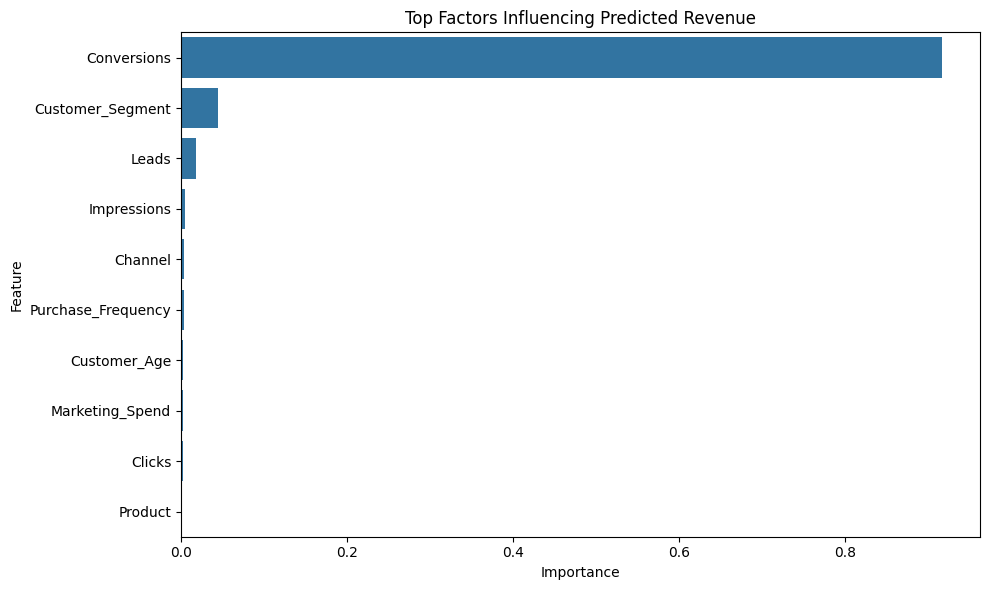

In [17]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": revenue_features,
    "Importance": revenue_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("TOP REVENUE DRIVERS")
display(importance.head(10))

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Factors Influencing Predicted Revenue"
)

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# AI BUDGET OPTIMIZATION
# ============================================================

TOTAL_BUDGET = 10_000_000   # ₹1 Crore

channels_list = channel_performance[
    "Channel"
].tolist()

n_channels = len(channels_list)

# ------------------------------------------------------------
# Estimate historical response characteristics
# ------------------------------------------------------------

channel_rates = {}

for channel in channels_list:

    temp = df[df["Channel"] == channel]

    avg_cpm = (
        temp["Marketing_Spend"].sum()
        /
        temp["Impressions"].sum()
    ) * 1000

    avg_ctr = (
        temp["Clicks"].sum()
        /
        temp["Impressions"].sum()
    )

    avg_cvr = (
        temp["Conversions"].sum()
        /
        temp["Clicks"].sum()
    )

    avg_aov = (
        temp["Revenue"].sum()
        /
        max(temp["Conversions"].sum(), 1)
    )

    channel_rates[channel] = {
        "CPM": avg_cpm,
        "CTR": avg_ctr,
        "CVR": avg_cvr,
        "AOV": avg_aov
    }


# ------------------------------------------------------------
# Revenue response function
# ------------------------------------------------------------

def estimate_channel_profit(
    channel,
    budget
):

    rates = channel_rates[channel]

    # Estimated impressions
    impressions = (
        budget /
        rates["CPM"]
    ) * 1000

    # Estimated clicks
    clicks = (
        impressions *
        rates["CTR"]
    )

    # Estimated conversions
    conversions = (
        clicks *
        rates["CVR"]
    )

    # Historical average order value
    base_revenue = (
        conversions *
        rates["AOV"]
    )

    # Diminishing returns
    # Larger budgets become progressively less efficient
    revenue = (
        base_revenue *
        (1 + 0.25 *
         np.exp(-budget / 3_000_000))
    )

    profit = revenue - budget

    return profit


# ------------------------------------------------------------
# Objective function
# ------------------------------------------------------------

def objective(budgets):

    total_profit = 0

    for i, channel in enumerate(channels_list):

        total_profit += estimate_channel_profit(
            channel,
            budgets[i]
        )

    return -total_profit


# ------------------------------------------------------------
# Constraints
# ------------------------------------------------------------

constraints = {
    "type": "eq",
    "fun": lambda x: np.sum(x) - TOTAL_BUDGET
}

# Minimum and maximum budget per channel
bounds = [
    (
        TOTAL_BUDGET * 0.05,
        TOTAL_BUDGET * 0.35
    )
    for _ in channels_list
]


# ------------------------------------------------------------
# Initial allocation
# ------------------------------------------------------------

initial_budget = np.array([
    TOTAL_BUDGET / n_channels
] * n_channels)


# ------------------------------------------------------------
# Run optimization
# ------------------------------------------------------------

result = minimize(
    objective,
    initial_budget,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

if result.success:

    recommended_budgets = result.x

else:

    print(
        "Optimization warning:",
        result.message
    )

    recommended_budgets = initial_budget


# ------------------------------------------------------------
# Recommendation table
# ------------------------------------------------------------

budget_recommendation = pd.DataFrame({
    "Channel": channels_list,
    "Current_Budget": [
        df[df["Channel"] == c]["Marketing_Spend"].sum()
        for c in channels_list
    ],
    "Recommended_Budget": recommended_budgets
})

budget_recommendation["Budget_Change"] = (
    budget_recommendation["Recommended_Budget"]
    -
    budget_recommendation["Current_Budget"]
)

budget_recommendation["Change_%"] = (
    budget_recommendation["Budget_Change"]
    /
    budget_recommendation["Current_Budget"]
) * 100

budget_recommendation = budget_recommendation.sort_values(
    "Recommended_Budget",
    ascending=False
)

print("AI RECOMMENDED MARKETING BUDGET")
print("================================")

display(
    budget_recommendation
)

AI RECOMMENDED MARKETING BUDGET


,Channel,Current_Budget,Recommended_Budget,Budget_Change,Change_%
0,Email,4.357866e+07,3.500000e+06,-4.007866e+07,-91.968546
1,Google Ads,4.515540e+07,3.500000e+06,-4.165540e+07,-92.248988
2,LinkedIn,4.344777e+07,1.096225e+06,-4.235155e+07,-97.476913
4,Instagram,4.129463e+07,7.184314e+05,-4.057620e+07,-98.260231
3,Meta Ads,4.357422e+07,6.853434e+05,-4.288888e+07,-98.427181
5,YouTube,4.551331e+07,5.000000e+05,-4.501331e+07,-98.901420


In [19]:
# ============================================================
# EXPECTED REVENUE & PROFIT FOR RECOMMENDED BUDGET
# ============================================================

expected_revenue = []
expected_profit = []

for _, row in budget_recommendation.iterrows():

    channel = row["Channel"]
    budget = row["Recommended_Budget"]

    rates = channel_rates[channel]

    impressions = (
        budget /
        rates["CPM"]
    ) * 1000

    clicks = (
        impressions *
        rates["CTR"]
    )

    conversions = (
        clicks *
        rates["CVR"]
    )

    revenue = (
        conversions *
        rates["AOV"]
    )

    profit = revenue - budget

    expected_revenue.append(revenue)
    expected_profit.append(profit)


budget_recommendation["Expected_Revenue"] = (
    expected_revenue
)

budget_recommendation["Expected_Profit"] = (
    expected_profit
)

budget_recommendation["Expected_ROAS"] = (
    budget_recommendation["Expected_Revenue"]
    /
    budget_recommendation["Recommended_Budget"]
)

display(
    budget_recommendation[
        [
            "Channel",
            "Current_Budget",
            "Recommended_Budget",
            "Budget_Change",
            "Change_%",
            "Expected_Revenue",
            "Expected_Profit",
            "Expected_ROAS"
        ]
    ]
)

,Channel,Current_Budget,Recommended_Budget,Budget_Change,Change_%,Expected_Revenue,Expected_Profit,Expected_ROAS
0,Email,4.357866e+07,3.500000e+06,-4.007866e+07,-91.968546,6.815286e+07,6.465286e+07,19.472245
1,Google Ads,4.515540e+07,3.500000e+06,-4.165540e+07,-92.248988,2.349892e+07,1.999892e+07,6.713977
2,LinkedIn,4.344777e+07,1.096225e+06,-4.235155e+07,-97.476913,3.194650e+06,2.098425e+06,2.914228
4,Instagram,4.129463e+07,7.184314e+05,-4.057620e+07,-98.260231,1.868885e+06,1.150454e+06,2.601341
3,Meta Ads,4.357422e+07,6.853434e+05,-4.288888e+07,-98.427181,1.779507e+06,1.094164e+06,2.596519
5,YouTube,4.551331e+07,5.000000e+05,-4.501331e+07,-98.901420,4.848029e+05,-1.519713e+04,0.969606


In [20]:
# ============================================================
# AI BUSINESS RECOMMENDATIONS
# ============================================================

print("\n")
print("=" * 70)
print("AI MARKETING BUDGET RECOMMENDATIONS")
print("=" * 70)

for _, row in budget_recommendation.iterrows():

    channel = row["Channel"]
    change = row["Change_%"]
    roas = row["Expected_ROAS"]

    if change > 10:

        print(
            f"📈 INCREASE {channel} by "
            f"{change:.1f}%."
        )

        print(
            f"   Expected ROAS: {roas:.2f}"
        )

        print(
            "   Reason: The optimization model "
            "predicts stronger expected profitability."
        )

    elif change < -10:

        print(
            f"📉 REDUCE {channel} by "
            f"{abs(change):.1f}%."
        )

        print(
            f"   Expected ROAS: {roas:.2f}"
        )

        print(
            "   Reason: The model predicts lower "
            "incremental profitability at the current allocation."
        )

    else:

        print(
            f"➡️ MAINTAIN {channel}."
        )

        print(
            f"   Expected ROAS: {roas:.2f}"
        )

    print("-" * 70)



AI MARKETING BUDGET RECOMMENDATIONS
📉 REDUCE Email by 92.0%.
   Expected ROAS: 19.47
   Reason: The model predicts lower incremental profitability at the current allocation.
----------------------------------------------------------------------
📉 REDUCE Google Ads by 92.2%.
   Expected ROAS: 6.71
   Reason: The model predicts lower incremental profitability at the current allocation.
----------------------------------------------------------------------
📉 REDUCE LinkedIn by 97.5%.
   Expected ROAS: 2.91
   Reason: The model predicts lower incremental profitability at the current allocation.
----------------------------------------------------------------------
📉 REDUCE Instagram by 98.3%.
   Expected ROAS: 2.60
   Reason: The model predicts lower incremental profitability at the current allocation.
----------------------------------------------------------------------
📉 REDUCE Meta Ads by 98.4%.
   Expected ROAS: 2.60
   Reason: The model predicts lower incremental profitability at t

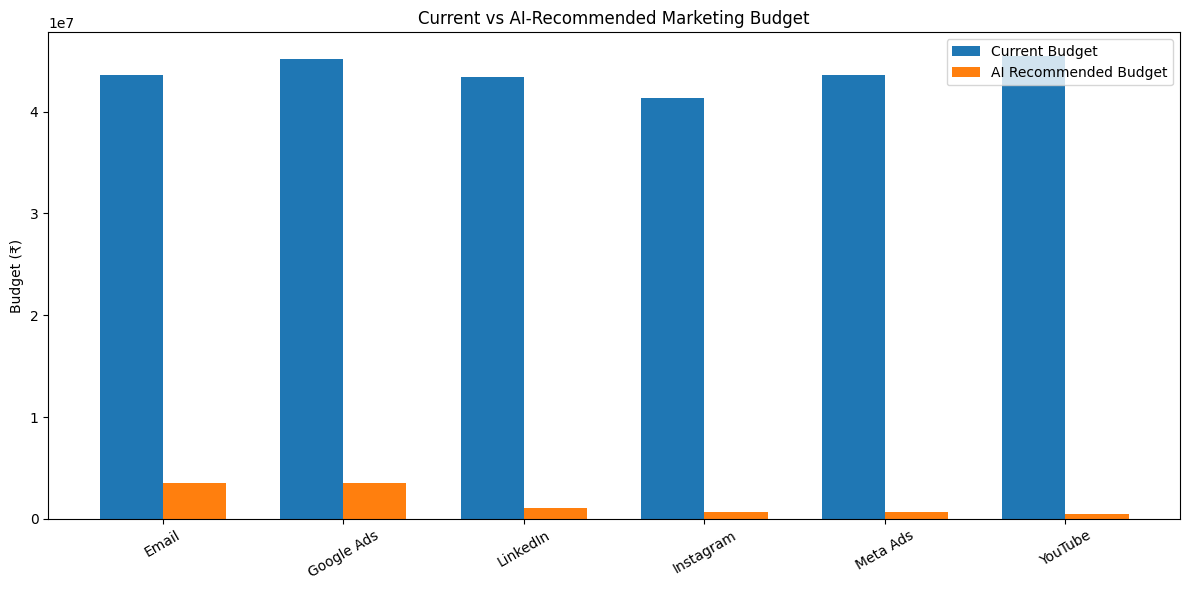

In [21]:
# ============================================================
# BUDGET COMPARISON
# ============================================================

plot_df = budget_recommendation.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    plot_df["Current_Budget"],
    width,
    label="Current Budget"
)

plt.bar(
    x + width/2,
    plot_df["Recommended_Budget"],
    width,
    label="AI Recommended Budget"
)

plt.xticks(
    x,
    plot_df["Channel"],
    rotation=30
)

plt.ylabel("Budget (₹)")
plt.title(
    "Current vs AI-Recommended Marketing Budget"
)

plt.legend()

plt.tight_layout()
plt.show()

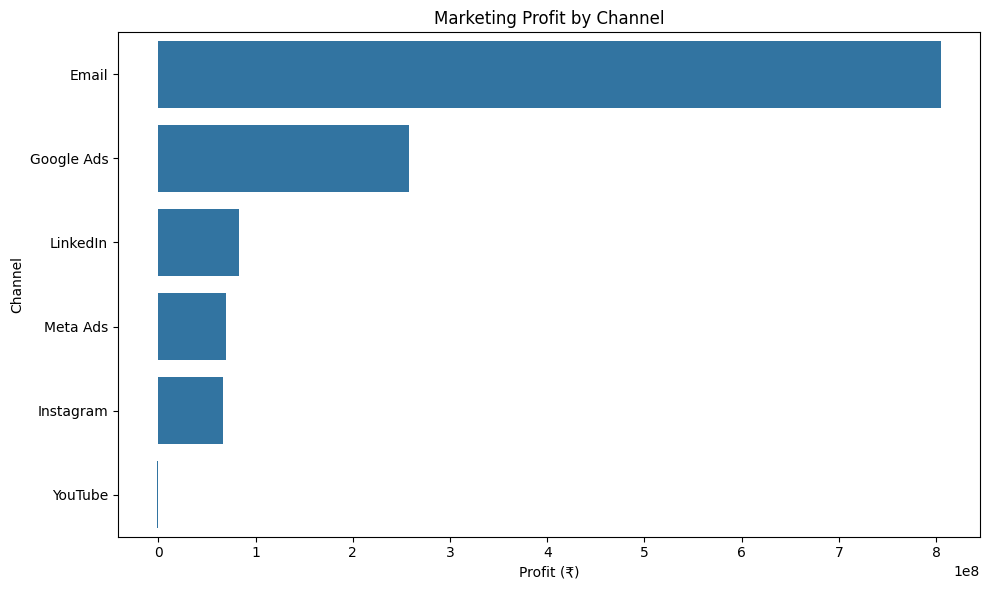

In [22]:
# ============================================================
# CHANNEL PROFITABILITY
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=channel_performance,
    x="Profit",
    y="Channel"
)

plt.title(
    "Marketing Profit by Channel"
)

plt.xlabel("Profit (₹)")
plt.ylabel("Channel")

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# EXECUTIVE SUMMARY
# ============================================================

total_spend = df["Marketing_Spend"].sum()
total_revenue = df["Revenue"].sum()
total_profit = df["Profit"].sum()

overall_roi = (
    total_profit /
    total_spend
) * 100

overall_roas = (
    total_revenue /
    total_spend
)

total_conversions = df["Conversions"].sum()

average_cac = (
    total_spend /
    max(total_conversions, 1)
)

print("\n")
print("=" * 70)
print("       AI MARKETING INTELLIGENCE DASHBOARD")
print("       FMCG / PRODUCT-BASED COMPANY")
print("=" * 70)

print(
    f"\nTotal Marketing Spend : ₹{total_spend:,.0f}"
)

print(
    f"Total Revenue         : ₹{total_revenue:,.0f}"
)

print(
    f"Total Profit          : ₹{total_profit:,.0f}"
)

print(
    f"Overall ROI           : {overall_roi:.2f}%"
)

print(
    f"Overall ROAS          : {overall_roas:.2f}"
)

print(
    f"Total Conversions     : {total_conversions:,.0f}"
)

print(
    f"Average CAC           : ₹{average_cac:,.2f}"
)

print("\nTop Channels by Profit:")

display(
    channel_performance[
        [
            "Channel",
            "Marketing_Spend",
            "Revenue",
            "Profit",
            "ROI",
            "ROAS",
            "CAC"
        ]
    ].head()
)

print("\nAI Budget Recommendation:")

display(
    budget_recommendation[
        [
            "Channel",
            "Current_Budget",
            "Recommended_Budget",
            "Change_%",
            "Expected_Revenue",
            "Expected_Profit",
            "Expected_ROAS"
        ]
    ]
)



       AI MARKETING INTELLIGENCE DASHBOARD
       FMCG / PRODUCT-BASED COMPANY

Total Marketing Spend : ₹262,563,990
Total Revenue         : ₹1,543,056,040
Total Profit          : ₹1,280,492,050
Overall ROI           : 487.69%
Overall ROAS          : 5.88
Total Conversions     : 1,272,636
Average CAC           : ₹206.32

Top Channels by Profit:


,Channel,Marketing_Spend,Revenue,Profit,ROI,ROAS,CAC
0,Email,4.357866e+07,8.485744e+08,8.049957e+08,1847.224501,19.472245,68.642732
1,Google Ads,4.515540e+07,3.031723e+08,2.580169e+08,571.397677,6.713977,173.403154
3,LinkedIn,4.344777e+07,1.266167e+08,8.316895e+07,191.422823,2.914228,522.755415
4,Meta Ads,4.357422e+07,1.131413e+08,6.956706e+07,159.651882,2.596519,366.848111
2,Instagram,4.129463e+07,1.074214e+08,6.612678e+07,160.134082,2.601341,344.880673



AI Budget Recommendation:


,Channel,Current_Budget,Recommended_Budget,Change_%,Expected_Revenue,Expected_Profit,Expected_ROAS
0,Email,4.357866e+07,3.500000e+06,-91.968546,6.815286e+07,6.465286e+07,19.472245
1,Google Ads,4.515540e+07,3.500000e+06,-92.248988,2.349892e+07,1.999892e+07,6.713977
2,LinkedIn,4.344777e+07,1.096225e+06,-97.476913,3.194650e+06,2.098425e+06,2.914228
4,Instagram,4.129463e+07,7.184314e+05,-98.260231,1.868885e+06,1.150454e+06,2.601341
3,Meta Ads,4.357422e+07,6.853434e+05,-98.427181,1.779507e+06,1.094164e+06,2.596519
5,YouTube,4.551331e+07,5.000000e+05,-98.901420,4.848029e+05,-1.519713e+04,0.969606
